In [87]:
# Import Libraries
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

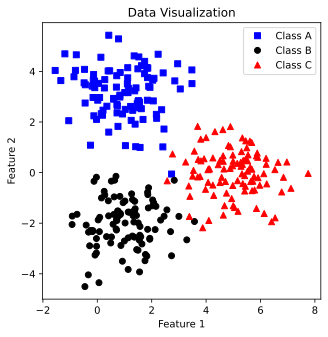

In [88]:
# Create data
num_samples = 100
# Create Data

num_samples = 100
blur = 1
A = [1, 3]
B = [1,-2]
C = [5, 0]

# generate data
a = [A[0] + np.random.randn(num_samples) *blur, A[1] + np.random.randn(num_samples) *blur]
b = [B[0] + np.random.randn(num_samples) *blur, B[1] + np.random.randn(num_samples) *blur]
c = [C[0] + np.random.randn(num_samples) *blur, C[1] + np.random.randn(num_samples) *blur]


# True labels
labels_np = np.vstack((np.zeros((num_samples, 1)), np.ones((num_samples, 1)), np.full((num_samples, 1), 2)))

# concatenate into a matrix
data_np = np.hstack((a, b, c)).T

# Convert to PyTorch tensors
data = torch.tensor(data_np).float()
labels = torch.squeeze(torch.tensor(labels_np).long())

# Visualize the data
figure = plt.figure(figsize=(5, 5))
plt.plot(data[np.where(labels == 0)[0], 0], data[np.where(labels == 0)[0], 1], 'bs', label='Class A')
plt.plot(data[np.where(labels == 1)[0], 0], data[np.where(labels == 1)[0], 1], 'ko', label='Class B')
plt.plot(data[np.where(labels == 2)[0], 0], data[np.where(labels == 2)[0], 1], 'r^', label='Class C')
plt.title('Data Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [ ]:
# Create model

ANN_model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 3),
    # nn.Softmax(dim=1)
    )

    # Loss function
loss_fn = nn.CrossEntropyLoss()
    # Optimizer
optimizer = torch.optim.SGD(ANN_model.parameters(), lr=0.01)
    


In [90]:
# Train ANN_model
num_epochs = 1000

losses = torch.zeros(num_epochs)
acum_accuracy = []


for epoch in range(num_epochs):
    # forward prop
    y_hat = ANN_model(data)
        # Compute loss
    loss = loss_fn(y_hat, labels)
    losses[epoch] = loss

    # Back propagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    matches = torch.argmax(y_hat, axis=1) == labels
    matches_num = matches.float()
    accuracy_pct = 100*torch.mean(matches_num)
    acum_accuracy.append(accuracy_pct)

    # final forward pass
predictions = ANN_model(data)

predlabels = torch.argmax(predictions, axis=1)
total_accuracy = 100*torch.mean((predlabels == labels).float())

total_accuracy


tensor(97.)

Final accuracy: 97%


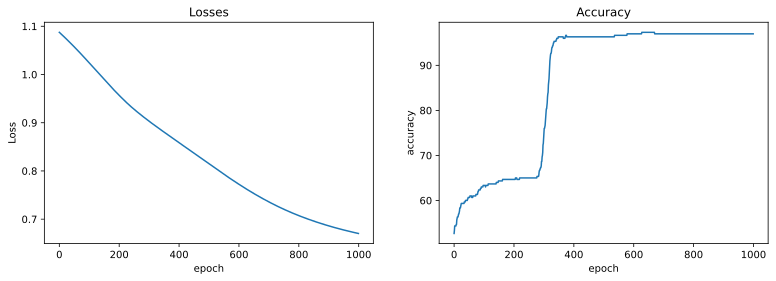

In [91]:
# report accuracy
print('Final accuracy: %g%%' %total_accuracy)

fig,ax = plt.subplots(1,2,figsize=(13,4))

ax[0].plot(losses.detach())
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('epoch')
ax[0].set_title('Losses')

ax[1].plot(acum_accuracy)
ax[1].set_ylabel('accuracy')
ax[1].set_xlabel('epoch')
ax[1].set_title('Accuracy')
plt.show()
